<a href="https://colab.research.google.com/github/Devaprakash917/Sales_Data_Analysis-using-python/blob/main/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Read Datasets

In [27]:
purchaseData=pd.read_csv("/content/QVI_purchase_behaviour.csv")

In [28]:
transactionData=pd.read_excel("/content/QVI_transaction_data.xlsx")

In [29]:
purchaseData.head(5)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [30]:
transactionData.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


Data Exploration

In [31]:
purchaseData.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [32]:
transactionData.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [33]:
purchaseData.duplicated().sum()

np.int64(0)

In [34]:
transactionData.duplicated().sum()

np.int64(1)

In [35]:
transactionData[transactionData.duplicated()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [36]:
transactionData.drop_duplicates(inplace=True)

In [37]:
purchaseData.dtypes

,0
LYLTY_CARD_NBR,int64
LIFESTAGE,object
PREMIUM_CUSTOMER,object


In [38]:
transactionData.dtypes

,0
DATE,int64
STORE_NBR,int64
LYLTY_CARD_NBR,int64
TXN_ID,int64
PROD_NBR,int64
PROD_NAME,object
PROD_QTY,int64
TOT_SALES,float64


In [39]:
transactionData['DATE']=pd.to_datetime(transactionData['DATE'],origin='1899-12-30',unit='D')

In [40]:
transactionData.dtypes

,0
DATE,datetime64[ns]
STORE_NBR,int64
LYLTY_CARD_NBR,int64
TXN_ID,int64
PROD_NBR,int64
PROD_NAME,object
PROD_QTY,int64
TOT_SALES,float64


In [41]:
transactionData['PROD_NAME'].value_counts()

,count
PROD_NAME,
Kettle Mozzarella Basil & Pesto 175g,3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g,3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,3269
Tyrrells Crisps Ched & Chives 165g,3268
Cobs Popd Sea Salt Chips 110g,3265
...,...
RRD Pc Sea Salt 165g,1431
Woolworths Medium Salsa 300g,1430
NCC Sour Cream & Garden Chives 175g,1419


In [42]:
transactionData['PROD_NAME'].info()

<class 'pandas.core.series.Series'>
Index: 264835 entries, 0 to 264835
Series name: PROD_NAME
Non-Null Count   Dtype 
--------------   ----- 
264835 non-null  object
dtypes: object(1)
memory usage: 4.0+ MB


In [43]:
transactionData['PROD_NAME'].describe()

,PROD_NAME
count,264835
unique,114
top,Kettle Mozzarella Basil & Pesto 175g
freq,3304


In [44]:
unique_products = transactionData["PROD_NAME"].dropna().unique()
words = [word for prod in unique_products for word in prod.split(" ")]
productWords = pd.DataFrame(words, columns=["words"])
print(productWords)

       words
0    Natural
1       Chip
2           
3           
4           
..       ...
818  Doritos
819    Salsa
820     Mild
821         
822     300g

[823 rows x 1 columns]


In [45]:
productWords["words"] = productWords["words"].str.replace(r"[^a-zA-Z0-9]", "", regex=True)

In [46]:
productWords['words'].value_counts()

,count
words,
,251
175g,26
Chips,21
150g,19
Smiths,16
...,...
Rst,1
Pork,1
Belly,1


Data that describes only Lays Products

In [47]:
transactionData["SALSA"] = transactionData["PROD_NAME"].str.lower().str.contains("salsa", na=False)
transactionData = transactionData[transactionData["SALSA"] == False]
transactionData = transactionData.drop(columns=["SALSA"])

In [48]:
transactionData.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246741,246741.000000,2.467410e+05,2.467410e+05,246741.000000,246741.000000,246741.000000
mean,2018-12-30 01:19:32.745510656,135.051212,1.355311e+05,1.351312e+05,56.351835,1.908061,7.321328
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756900e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351840e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026540e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787231,8.071542e+04,7.814786e+04,33.695488,0.659832,3.077833


Detecting Outliers

In [49]:
outliers=transactionData[transactionData['PROD_QTY']>transactionData['PROD_QTY'].mean()+5*transactionData['PROD_QTY'].std()]
print(outliers)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [50]:
cust_info=transactionData[transactionData['LYLTY_CARD_NBR']==226000]
print(cust_info)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


It looks like this customer has only had the two transactions over the year and is
not an ordinary retail customer. The customer might be buying chips for commercial
purposes instead. We'll remove this loyalty card number from further analysis.

In [51]:
transactionData

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [52]:
transactionData=transactionData[transactionData['LYLTY_CARD_NBR']!=226000]
transactionData

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


 number of transactions by date

In [53]:
daily_txn = (
    transactionData
    .groupby("DATE")
    .size()
    .reset_index(name='count'))
daily_txn

,DATE,count
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660
...,...,...
359,2019-06-26,657
360,2019-06-27,669
361,2019-06-28,673
362,2019-06-29,703


There's only 364 rows, meaning only 364 dates which indicates a missing date. Let's
create a sequence of dates from 1 Jul 2018 to 30 Jun 2019 and use this to create a
chart of number of transactions over time to find the missing date.


In [54]:
date_range = pd.date_range(start="2018-07-01", end="2019-06-30")
date_df = pd.DataFrame({"DATE": date_range})

join this the count of transactions by date

In [55]:
full_data = date_df.merge(daily_txn, on="DATE", how="left")

In [56]:
full_data["count"] = full_data["count"].fillna(0).astype(int)

In [57]:
missing_dates = full_data[full_data["count"] == 0]
print(missing_dates)

          DATE  count
177 2018-12-25      0


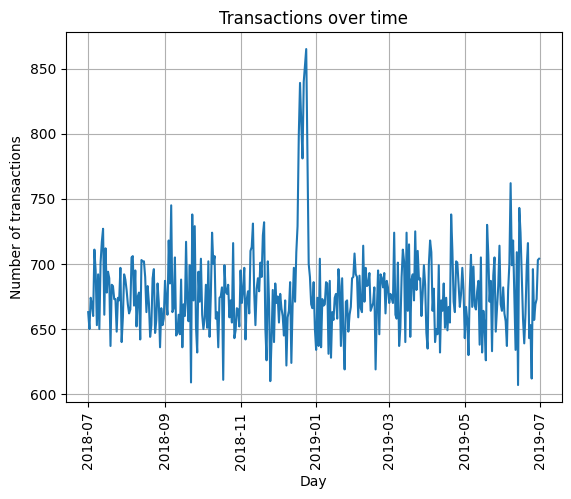

In [58]:
plt.figure()

plt.plot(daily_txn["DATE"], daily_txn['count'])
#Labels and Titles
plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.title("Transactions over time")

# Rotate x-axis labels
plt.xticks(rotation=90)

# Show grid (similar to theme_bw)
plt.grid(True)

plt.show()

We can see that there is an increase in purchases in December and a break in late
December. Let's zoom in on this.


In [59]:
december_data = transactionData[transactionData["DATE"].dt.month == 12]

In [60]:
december_data_tra=(december_data.groupby("DATE").size().reset_index(name="count"))

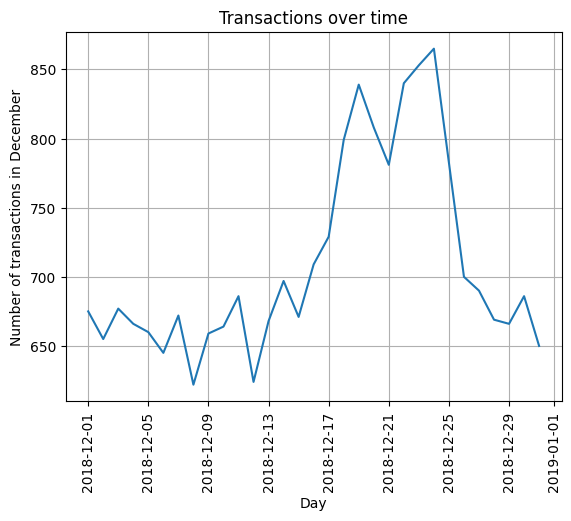

In [61]:
plt.figure()

plt.plot(december_data_tra["DATE"], december_data_tra['count'])
#Labels and Titles
plt.xlabel("Day")
plt.ylabel("Number of transactions in December")
plt.title("Transactions over time")

# Rotate x-axis labels
plt.xticks(rotation=90)

# Show grid (similar to theme_bw)
plt.grid(True)

plt.show()

We can see that the increase in sales occurs in the lead-up to Christmas and that
there are zero sales on Christmas day itself. This is due to shops being closed on
Christmas day.

Create PACK_SIZE by extracting digits from PROD_NAME

In [62]:
transactionData["PACK_SIZE"] = transactionData["PROD_NAME"].str.extract(r"(\d+\.?\d*)").astype(float)

/tmp/ipykernel_2391/1572713925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactionData["PACK_SIZE"] = transactionData["PROD_NAME"].str.extract(r"(\d+\.?\d*)").astype(float)


In [63]:
transactionData

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0
...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175.0
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175.0
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170.0
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150.0


In [64]:
transactionData['PACK_SIZE'].value_counts()

,count
PACK_SIZE,
175.0,66389
150.0,40203
134.0,25102
110.0,22387
170.0,19983
165.0,15297
330.0,12540
380.0,6416
270.0,6285


The largest size is 380g and the smallest size is 70g

Text(0.5, 1.0, 'Histogram of Pack Size')

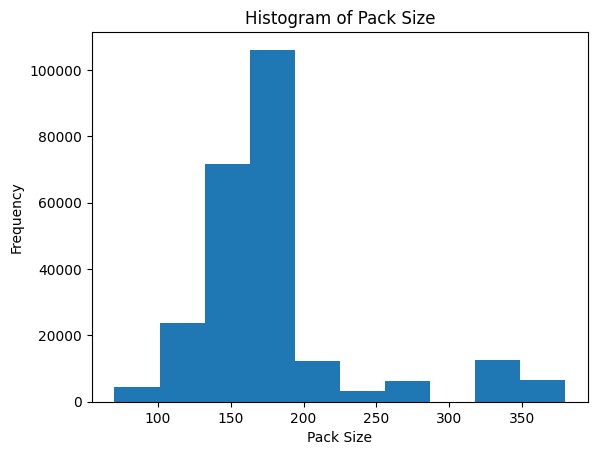

In [65]:
plt.hist(transactionData['PACK_SIZE'])
plt.xlabel('Pack Size')
plt.ylabel('Frequency')
plt.title('Histogram of Pack Size')

In [66]:
transactionData['PROD_NAME']

,PROD_NAME
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
...,...
264831,Kettle Sweet Chilli And Sour Cream 175g
264832,Tostitos Splash Of Lime 175g
264833,Doritos Mexicana 170g
264834,Doritos Corn Chip Mexican Jalapeno 150g


Create BRAND name using PROD_NAME column

In [67]:
transactionData['BRAND']=transactionData['PROD_NAME'].str.split().str[0]

/tmp/ipykernel_2391/2933643353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactionData['BRAND']=transactionData['PROD_NAME'].str.split().str[0]


In [68]:
transactionData

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175.0,Kettle
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175.0,Tostitos
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170.0,Doritos
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150.0,Doritos


In [69]:
transactionData['BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

Some of the brand names look like they are of the same brands - such as RED and
RRD, which are both Red Rock Deli chips so merge both and also 'Natural' - organic ,'Dorito' - Doritos, 'Smith' - Smiths

In [70]:
transactionData['BRAND']=transactionData['BRAND'].replace({"RRD":"Red"})
transactionData['BRAND']=transactionData['BRAND'].replace({"Natural":"Organic",'Dorito':'Doritos','Smith':'Smiths'})

/tmp/ipykernel_2391/2177078970.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactionData['BRAND']=transactionData['BRAND'].replace({"RRD":"Red"})
/tmp/ipykernel_2391/2177078970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactionData['BRAND']=transactionData['BRAND'].replace({"Natural":"Organic",'Dorito':'Doritos','Smith':'Smiths'})


In [71]:
transactionData['BRAND'].value_counts()

,count
BRAND,
Kettle,41288
Smiths,30352
Doritos,25224
Pringles,25102
Red,16321
Thins,14075
Infuzions,11057
WW,10320
Cobs,9693


Exploratory Data Analysis(EDA) on purchaseData

In [72]:
purchaseData

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [73]:
purchaseData.shape

(72637, 3)

In [74]:
purchaseData.dtypes

,0
LYLTY_CARD_NBR,int64
LIFESTAGE,object
PREMIUM_CUSTOMER,object


Summary of purchaseData

In [75]:
purchaseData.describe(include='all')

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
count,7.263700e+04,72637,72637
unique,NaN,7,3
top,NaN,RETIREES,Mainstream
freq,NaN,14805,29245
mean,1.361859e+05,NaN,NaN
std,8.989293e+04,NaN,NaN
min,1.000000e+03,NaN,NaN
25%,6.620200e+04,NaN,NaN
50%,1.340400e+05,NaN,NaN
75%,2.033750e+05,NaN,NaN


In [76]:
purchaseData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


Merging Both Purchasedata and transactiondata into merged_data

In [77]:
merged_data=pd.merge(transactionData,purchaseData,on='LYLTY_CARD_NBR',how='left')

In [78]:
transactionData.shape

(246739, 10)

In [79]:
merged_data.shape

(246739, 12)

As the number of rows in data is the same as that of transactionData we can be
sure that no duplicates were created

In [80]:
merged_data.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [81]:
merged_data.to_csv('QVI_data.csv', index=False)

In [82]:
from google.colab import files
files.download('QVI_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Organic,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


- Who spends the most on chips (total sales), describing customers by lifestage and
how premium their general purchasing behaviour is


In [84]:
chip_sales=merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])["TOT_SALES"].sum().reset_index()

In [85]:
chip_sales.sort_values(by='TOT_SALES',ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123531.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


- How many customers are in each segment


In [86]:
lifestyle_Premium=merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).size().reset_index()

In [87]:
lifestyle_Premium.rename(columns={0:'count_of_customers'},inplace=True)

In [88]:
lifestyle_Premium

,LIFESTAGE,PREMIUM_CUSTOMER,count_of_customers
0,MIDAGE SINGLES/COUPLES,Budget,4691
1,MIDAGE SINGLES/COUPLES,Mainstream,11095
2,MIDAGE SINGLES/COUPLES,Premium,7612
3,NEW FAMILIES,Budget,2824
4,NEW FAMILIES,Mainstream,2185
5,NEW FAMILIES,Premium,1488
6,OLDER FAMILIES,Budget,21514
7,OLDER FAMILIES,Mainstream,13241
8,OLDER FAMILIES,Premium,10403
9,OLDER SINGLES/COUPLES,Budget,17172


- How many chips are bought per customer by segment


In [89]:
chips_quantity=merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER','LYLTY_CARD_NBR'])["PROD_QTY"].sum().reset_index()
chips_quantity

,LIFESTAGE,PREMIUM_CUSTOMER,LYLTY_CARD_NBR,PROD_QTY
0,MIDAGE SINGLES/COUPLES,Budget,1052,1
1,MIDAGE SINGLES/COUPLES,Budget,1081,4
2,MIDAGE SINGLES/COUPLES,Budget,1184,1
3,MIDAGE SINGLES/COUPLES,Budget,1307,6
4,MIDAGE SINGLES/COUPLES,Budget,1343,2
...,...,...,...,...
71282,YOUNG SINGLES/COUPLES,Premium,272236,4
71283,YOUNG SINGLES/COUPLES,Premium,272319,4
71284,YOUNG SINGLES/COUPLES,Premium,272358,1
71285,YOUNG SINGLES/COUPLES,Premium,272379,4


- What's the average chip price by customer segment

In [90]:
chips_avg=merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER',])["TOT_SALES"].mean().reset_index()
chips_avg

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Budget,7.108442
1,MIDAGE SINGLES/COUPLES,Mainstream,7.637156
2,MIDAGE SINGLES/COUPLES,Premium,7.152371
3,NEW FAMILIES,Budget,7.297256
4,NEW FAMILIES,Mainstream,7.313364
5,NEW FAMILIES,Premium,7.231720
6,OLDER FAMILIES,Budget,7.291241
7,OLDER FAMILIES,Mainstream,7.281440
8,OLDER FAMILIES,Premium,7.232779
9,OLDER SINGLES/COUPLES,Budget,7.444305


- The customer's total spend over the period and total spend for each transaction
to understand what proportion of their grocery spend is on chips

In [91]:
customer_total_spend = (
    merged_data
    .groupby("LYLTY_CARD_NBR")["TOT_SALES"]
    .sum()
    .reset_index(name="TOTAL_SPEND")
)

In [92]:
transaction_spend = (
    merged_data
    .groupby(["LYLTY_CARD_NBR", "TXN_ID"])["TOT_SALES"]
    .sum()
    .reset_index(name="TXN_SPEND")
)

In [93]:
merged = transaction_spend.merge(
    customer_total_spend,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [94]:
merged["SPEND_PROPORTION"] = merged["TXN_SPEND"] / merged["TOTAL_SPEND"]
merged

,LYLTY_CARD_NBR,TXN_ID,TXN_SPEND,TOTAL_SPEND,SPEND_PROPORTION
0,1000,1,6.0,6.0,1.000000
1,1002,2,2.7,2.7,1.000000
2,1003,3,3.6,6.6,0.545455
3,1003,4,3.0,6.6,0.454545
4,1004,5,1.9,1.9,1.000000
...,...,...,...,...,...
245252,2370651,240350,13.0,13.0,1.000000
245253,2370701,240378,7.2,7.2,1.000000
245254,2370751,240394,9.2,9.2,1.000000
245255,2370961,240480,8.4,8.4,1.000000


- Proportion of customers in each customer segment overall to compare against the
mix of customers who purchase chips


In [95]:
segment_sales=(
    merged_data
    .groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES']
    .sum()
    .reset_index(name='segment_sales')
)
segment_sales=segment_sales.sort_values(by='segment_sales',ascending=False)
segment_sales

,LIFESTAGE,PREMIUM_CUSTOMER,segment_sales
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123531.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


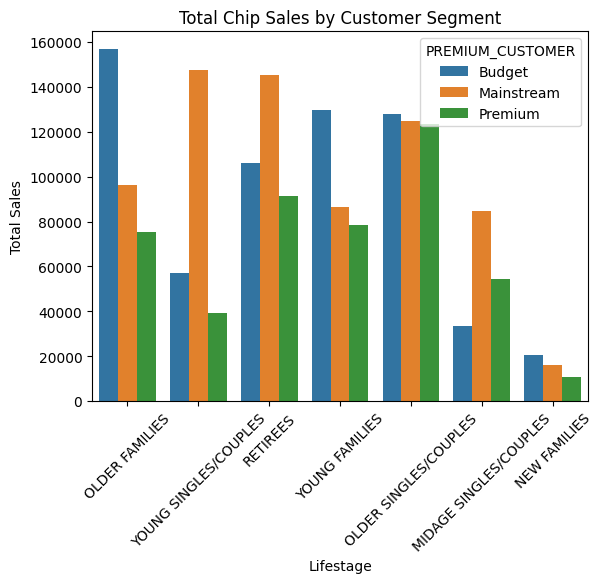

In [96]:
plt.figure()
sns.barplot(data=segment_sales,x="LIFESTAGE",y="segment_sales",hue="PREMIUM_CUSTOMER")

plt.xticks(rotation=45)
plt.title("Total Chip Sales by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.show()

Sales are coming mainly from Budget - older families, Mainstream - young
singles/couples, and Mainstream - retirees


 Number of customers by LIFESTAGE and PREMIUM_CUSTOMER

In [97]:
customer_count=(
    merged_data
    .groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
    .size()
    .reset_index(name='customer_count')
)
customer_count=customer_count.sort_values(by='customer_count',ascending=False)
customer_count

,LIFESTAGE,PREMIUM_CUSTOMER,customer_count
6,OLDER FAMILIES,Budget,21514
13,RETIREES,Mainstream,19970
19,YOUNG SINGLES/COUPLES,Mainstream,19544
15,YOUNG FAMILIES,Budget,17763
9,OLDER SINGLES/COUPLES,Budget,17172
10,OLDER SINGLES/COUPLES,Mainstream,17061
11,OLDER SINGLES/COUPLES,Premium,16559
12,RETIREES,Budget,14225
7,OLDER FAMILIES,Mainstream,13241
14,RETIREES,Premium,12236


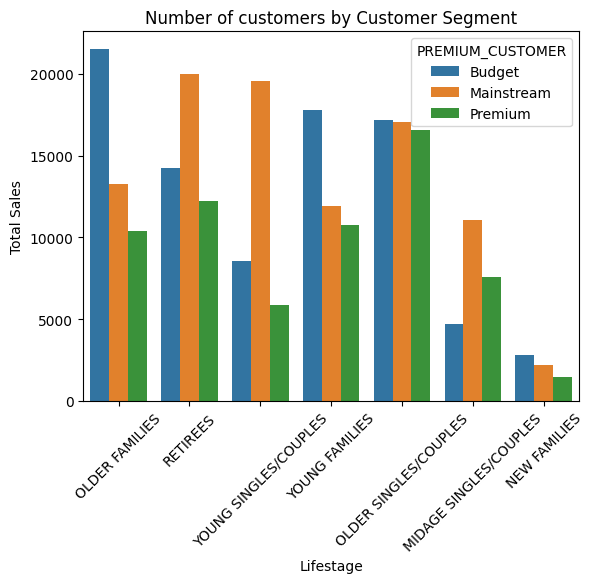

In [98]:
plt.figure()
sns.barplot(data=customer_count,x="LIFESTAGE",y="customer_count",hue="PREMIUM_CUSTOMER")

plt.xticks(rotation=45)
plt.title("Number of customers by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.show()

There are more Mainstream - young singles/couples and Mainstream - retirees who buy
chips. This contributes to there being more sales to these customer segments but
this is not a major driver for the Budget - Older families segment.

Average number of units per customer by LIFESTAGE and PREMIUM_CUSTOMER

In [99]:
total_units = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"]
    .sum()
    .reset_index(name="total_units")
)

In [100]:
customer_count = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .reset_index(name="num_customers")
)

In [101]:
avg_units = total_units.merge(
    customer_count,
    on=["LIFESTAGE", "PREMIUM_CUSTOMER"]
)

In [102]:
avg_units["avg_units_per_customer"] = (
    avg_units["total_units"] / avg_units["num_customers"]
)

In [129]:
avg_units.sort_values(by='avg_units_per_customer',ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,total_units,num_customers,avg_units_per_customer
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
6,OLDER FAMILIES,Budget,41853,4611,9.076773
8,OLDER FAMILIES,Premium,20239,2231,9.071717
15,YOUNG FAMILIES,Budget,34482,3953,8.722995
17,YOUNG FAMILIES,Premium,20901,2398,8.716013
16,YOUNG FAMILIES,Mainstream,23194,2685,8.638361
9,OLDER SINGLES/COUPLES,Budget,32883,4849,6.781398
11,OLDER SINGLES/COUPLES,Premium,31693,4682,6.769116
10,OLDER SINGLES/COUPLES,Mainstream,32607,4858,6.712021
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080


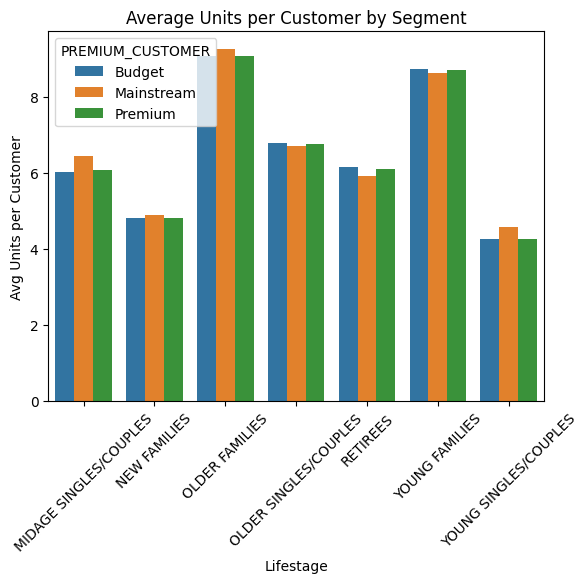

In [104]:
plt.figure()
sns.barplot(
    data=avg_units,
    x="LIFESTAGE",
    y="avg_units_per_customer",
    hue="PREMIUM_CUSTOMER"
)

plt.xticks(rotation=45)
plt.title("Average Units per Customer by Segment")
plt.xlabel("Lifestage")
plt.ylabel("Avg Units per Customer")
plt.show()

Older families and young families in general buy more chips per customer

Average price per unit by LIFESTAGE and PREMIUM_CUSTOMER

In [105]:
price_per_unit=(
    merged_data
    .groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
    .agg({"TOT_SALES": "sum",
        "PROD_QTY": "sum"})
    .reset_index()
)
price_per_unit['price_per_unit']=price_per_unit['TOT_SALES']/price_per_unit['PROD_QTY']
price_per_unit

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,PROD_QTY,price_per_unit
0,MIDAGE SINGLES/COUPLES,Budget,33345.70,8883,3.753878
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,21213,3.994449
2,MIDAGE SINGLES/COUPLES,Premium,54443.85,14400,3.780823
3,NEW FAMILIES,Budget,20607.45,5241,3.931969
4,NEW FAMILIES,Mainstream,15979.70,4060,3.935887
5,NEW FAMILIES,Premium,10760.80,2769,3.886168
6,OLDER FAMILIES,Budget,156863.75,41853,3.747969
7,OLDER FAMILIES,Mainstream,96413.55,25804,3.736380
8,OLDER FAMILIES,Premium,75242.60,20239,3.717703
9,OLDER SINGLES/COUPLES,Budget,127833.60,32883,3.887529


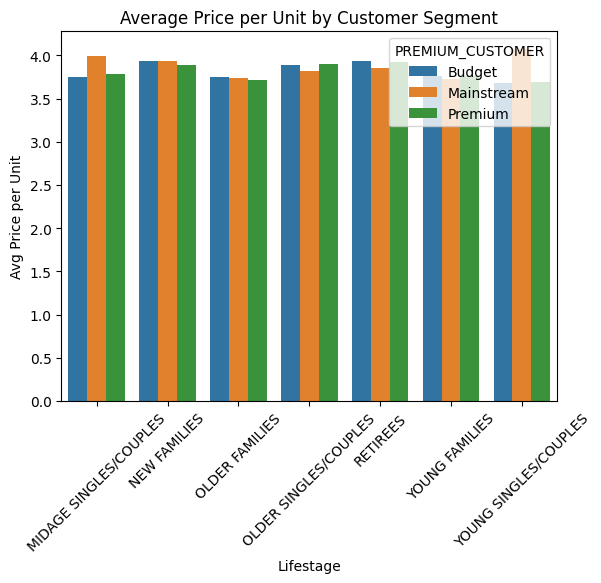

In [106]:
plt.figure()
sns.barplot(
    data=price_per_unit,
    x="LIFESTAGE",
    y="price_per_unit",
    hue="PREMIUM_CUSTOMER"
)

plt.xticks(rotation=45)
plt.title("Average Price per Unit by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Avg Price per Unit")
plt.show()

Mainstream midage and young singles and couples are more willing to pay more per
packet of chips compared to their budget and premium counterparts. This may be due
to premium shoppers being more likely to buy healthy snacks and when they buy
chips, this is mainly for entertainment purposes rather than their own consumption.
This is also supported by there being fewer premium midage and young singles and
couples buying chips compared to their mainstream counterparts.

Perform an independent t-test between mainstream vs premium and budget midage
and young singles and couples

In [107]:
merged_data['price_per_unit']=merged_data['TOT_SALES']/merged_data['PROD_QTY']

In [131]:
main_stream=merged_data[(merged_data['PREMIUM_CUSTOMER']=='Mainstream') & (merged_data["LIFESTAGE"].isin(["MIDAGE SINGLES/COUPLES", "YOUNG SINGLES/COUPLES"]))]['price_per_unit']
main_stream

,price_per_unit
4692,4.4
4693,4.4
4694,5.4
4695,4.4
4696,4.6
...,...
240883,3.8
240884,4.6
240885,3.7
240886,3.7


In [134]:
premium=merged_data[(merged_data["LIFESTAGE"].isin(["MIDAGE SINGLES/COUPLES", "YOUNG SINGLES/COUPLES"])) & (merged_data['PREMIUM_CUSTOMER'].isin(['Premium','Budget']))]['price_per_unit']
premium

,price_per_unit
0,3.00
1,2.10
2,1.45
3,3.00
4,4.60
...,...
246734,5.40
246735,4.40
246736,4.40
246737,3.90


In [135]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(main_stream, premium, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 37.6243885962295
p-value: 6.967354233018139e-306


The t-test results in a p-value of , i.e. 6.967354233018139e-306
the unit price for mainstream,
young and mid-age singles and couples are significantly higher than
that of budget or premium, young and midage singles and couples.

target customer segments that contribute the most to sales to
retain them or further increase sales  Let's look at Mainstream - young
singles/couples.

In [119]:
target=merged_data[(merged_data['LIFESTAGE']=="YOUNG SINGLES/COUPLES")& (merged_data['PREMIUM_CUSTOMER']=='Mainstream')]
target

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,price_per_unit
221344,2018-08-16,1,1020,26,19,Smiths Crinkle Cut Snag&Sauce 150g,1,2.6,150.0,Smiths,YOUNG SINGLES/COUPLES,Mainstream,2.6
221345,2018-08-17,1,1163,188,46,Kettle Original 175g,1,5.4,175.0,Kettle,YOUNG SINGLES/COUPLES,Mainstream,5.4
221346,2018-08-14,1,1291,333,27,WW Supreme Cheese Corn Chips 200g,1,1.9,200.0,WW,YOUNG SINGLES/COUPLES,Mainstream,1.9
221347,2019-05-15,3,3031,1227,14,Smiths Crnkle Chip Orgnl Big Bag 380g,1,5.9,380.0,Smiths,YOUNG SINGLES/COUPLES,Mainstream,5.9
221348,2019-05-18,3,3118,1574,62,Pringles Mystery Flavour 134g,1,3.7,134.0,Pringles,YOUNG SINGLES/COUPLES,Mainstream,3.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240883,2018-12-01,272,272377,270186,75,Cobs Popd Sea Salt Chips 110g,2,7.6,110.0,Cobs,YOUNG SINGLES/COUPLES,Mainstream,3.8
240884,2018-07-27,272,272389,270200,114,Kettle Sensations Siracha Lime 150g,2,9.2,150.0,Kettle,YOUNG SINGLES/COUPLES,Mainstream,4.6
240885,2018-11-10,272,272389,270201,26,Pringles Sweet&Spcy BBQ 134g,2,7.4,134.0,Pringles,YOUNG SINGLES/COUPLES,Mainstream,3.7
240886,2019-04-01,272,272389,270202,62,Pringles Mystery Flavour 134g,2,7.4,134.0,Pringles,YOUNG SINGLES/COUPLES,Mainstream,3.7


In [121]:
target_brand = (
    target["BRAND"]
    .value_counts(normalize=True)
    .reset_index()
)
target_brand.columns = ["BRAND", "target_prop"]
target_brand

,BRAND,target_prop
0,Kettle,0.196684
1,Doritos,0.121725
2,Pringles,0.118451
3,Smiths,0.098291
4,Thins,0.059660
5,Infuzions,0.049222
6,Twisties,0.046050
7,Tostitos,0.045538
8,Red,0.044771
9,Cobs,0.044208


In [123]:
overall_brand = (
    merged_data["BRAND"]
    .value_counts(normalize=True)
    .reset_index()
)
overall_brand.columns = ["BRAND", "overall_prop"]
overall_brand

,BRAND,overall_prop
0,Kettle,0.167335
1,Smiths,0.123013
2,Doritos,0.102229
3,Pringles,0.101735
4,Red,0.066147
5,Thins,0.057044
6,Infuzions,0.044813
7,WW,0.041826
8,Cobs,0.039284
9,Tostitos,0.038385


In [124]:
brand_compare = target_brand.merge(
    overall_brand,
    on="BRAND"
)

brand_compare["difference"] = (
    brand_compare["target_prop"] - brand_compare["overall_prop"]
)

brand_compare = brand_compare.sort_values(
    by="difference", ascending=False
)

print(brand_compare.head())

      BRAND  target_prop  overall_prop  difference
0    Kettle     0.196684      0.167335    0.029350
1   Doritos     0.121725      0.102229    0.019496
2  Pringles     0.118451      0.101735    0.016716
6  Twisties     0.046050      0.038316    0.007734
7  Tostitos     0.045538      0.038385    0.007154


Preferred pack size compared to the rest of the population

In [125]:
target_pack = (
    target["PACK_SIZE"]
    .value_counts(normalize=True)
    .reset_index()
)
target_pack.columns = ["PACK_SIZE", "target_prop"]

In [126]:
overall_pack = (
    merged_data["PACK_SIZE"]
    .value_counts(normalize=True)
    .reset_index()
)
overall_pack.columns = ["PACK_SIZE", "overall_prop"]

In [127]:
pack_compare = target_pack.merge(
    overall_pack,
    on="PACK_SIZE"
)

pack_compare["difference"] = (
    pack_compare["target_prop"] - pack_compare["overall_prop"]
)

pack_compare = pack_compare.sort_values(
    by="difference", ascending=False
)

print(pack_compare.head())

   PACK_SIZE  target_prop  overall_prop  difference
2      134.0     0.118451      0.101735    0.016716
3      110.0     0.104943      0.090732    0.014211
5      330.0     0.061144      0.050823    0.010321
8      270.0     0.031723      0.025472    0.006251
7      380.0     0.032030      0.026003    0.006027


Sales have mainly been due to Budget - older families, Mainstream - young singles/couples, and Mainstream retirees shoppers. We found that the high spend in chips for mainstream young singles/couples and retirees is due to there being more of them than other buyers. Mainstream, midage and young singles and
couples are also more likely to pay more per packet of chips. This is indicative of impulse buying behaviour.
We’ve also found that Mainstream young singles and couples are 23% more likely to purchase Tyrrells chips
compared to the rest of the population. The Category Manager may want to increase the category’s performance by off-locating some Tyrrells and smaller packs of chips in discretionary space near segments
where young singles and couples frequent more often to increase visibilty and impulse behaviour.
